In [1]:
import os
import sys
import random
import numpy as np
from pathlib import Path

os.chdir(next(p for p in Path.cwd().parents if (p / 'src').exists()))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"
os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

import tensorflow as tf

2026-10-03 15:16:22.597033: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791033382.610194   74677 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791033382.614561   74677 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791033382.625358   74677 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791033382.625367   74677 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791033382.625368   74677 computation_placer.cc:177] computation placer alr

In [2]:
from src.networks.DecoderPINN import PINN
from src.data.collocation import generate_boundary_grid, generate_interior_grid
from src.physics.physics import get_M_non_const
from src.data.decoder_dataloader import load_fem_data
from src.visualization.historyplots import plot_lbfgs_history
from src.visualization.pdeplots import plot_pinn_solution
from src.hyperparameters import hypers_fixedscar as h
from src.optimization.DecoderTrainer import DecoderTrainer

tf.keras.backend.clear_session()
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

In [3]:
# File paths
output_dir = 'models/pipeline_evolution/02_fixed_scar'
results_dir = 'results/pipeline_evolution/02_fixed_scar'
data_path = 'data/fixed_scar/dataset.npz'
scale_path = 'data/fixed_scar/u_scale.npy'

os.makedirs(output_dir, exist_ok=True)

# Load FEM data and scale
(x_train_pinn, u_train_pinn), (x_val_pinn, u_val_pinn), (x_test_pinn, u_test_pinn), U_SCALE = load_fem_data(
    data_path=data_path,
    scale_save_path=scale_path,
    number_type=number_type)

Loading FEM data from:
data/fixed_scar/dataset.npz
U_SCALE: 0.0633802938996219
Shape x_train: (2000, 2)
Shape x_val:   (500, 2)
Shape x_test:  (500, 2)


I0000 00:00:1791033385.487054   74677 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


In [4]:
# Model creation
model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1, 2), dtype=number_type))  

# Transfer Learning
pretrained_weights = os.path.join(output_dir, 'decoder_adam.weights.h5')
model.load_weights(pretrained_weights)
print(f"Transfer Learning from Adam weights: {pretrained_weights}")

# Generation 
N_interior = h.N_INTERIOR_LBFGS
N_activation = h.N_ACTIVATION_LBFGS
N_boundary = h.N_BOUNDARY_LBFGS

x_int = generate_interior_grid(N_interior, split_scar=0.6, dtype=number_type)
x_boundary, n_boundary = generate_boundary_grid(N_activation=N_activation, N_neumann=N_boundary, r=1.0 / 400, dtype=number_type)

num_neumann = 4 * N_boundary

x_int = tf.cast(x_int, dtype=number_type)
x_boundary = tf.cast(x_boundary, dtype=number_type)
n_boundary = tf.cast(n_boundary, dtype=number_type)

Transfer Learning from Adam weights: models/pipeline_evolution/02_fixed_scar/decoder_adam.weights.h5


In [5]:
# LOSS PARAMETERS
lambdas = {
    'pde': h.LAMBDA_PDE_LBFGS,
    'neu': h.LAMBDA_NEU_LBFGS,
    'dir': h.LAMBDA_DIR_LBFGS,
    'data': h.LAMBDA_DATA_LBFGS
}

trainer = DecoderTrainer(model=model, output_dir=output_dir, result_dir=results_dir)

trainer.train_lbfgs(x_int=x_int,
                    x_boundary=x_boundary,
                    n_boundary=n_boundary,
                    num_neumann=num_neumann,
                    x_data=x_train_pinn,
                    u_data=u_train_pinn,
                    x_val=x_val_pinn,
                    u_val=u_val_pinn,
                    physics_fn=get_M_non_const,
                    lambdas=lambdas,
                    max_iterations=h.MAX_LBFGS_ITERATIONS,
                    num_correction_pairs=h.NUM_CORRECTION_PAIRS_LBFGS,
                    tolerance=h.TOLERANCE_LBFGS,
                    x_tolerance=h.X_TOLERANCE_LBFGS,
                    f_relative_tolerance=h.F_RELATIVE_TOLERANCE_LBFGS,
                    number_type=number_type)


Starting L-BFGS optimization...


I0000 00:00:1791033387.550390   74677 service.cc:152] XLA service 0x5f364fa04450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791033387.550434   74677 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1791033387.925054   74677 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1791033389.622123   74677 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Call to loss_grad: 0 | Loss: 0.0011176079181648879 | PDE: 0.00059820358363904308 | Dir: 3.1553780945772837e-06 | Neu: 6.8432211485268328e-05 | Data: 4.1941834209480374e-05 | Validation: 2.630545537692642e-05
Call to loss_grad: 500 | Loss: 0.00041829706661240058 | PDE: 0.00018764517050179222 | Dir: 3.5187041812554737e-06 | Neu: 4.2996218942373217e-05 | Data: 1.524686353556804e-05 | Validation: 3.2140880657356691e-05
Call to loss_grad: 1000 | Loss: 0.00031487808576360075 | PDE: 0.00013668868492122221 | Dir: 2.6372853278000497e-06 | Neu: 4.0982312376014027e-05 | Data: 1.1083423518836402e-05 | Validation: 2.7376329596238066e-05
Call to loss_grad: 1500 | Loss: 0.00025501283469496976 | PDE: 0.00011265169081409116 | Dir: 2.1677365596547427e-06 | Neu: 3.5090936043447537e-05 | Data: 8.5592842240883641e-06 | Validation: 2.3893311880051281e-05
Call to loss_grad: 2000 | Loss: 0.00021931068969190635 | PDE: 9.9378467048206163e-05 | Dir: 2.2476708422726417e-06 | Neu: 2.780627308609096e-05 | Data: 6.9

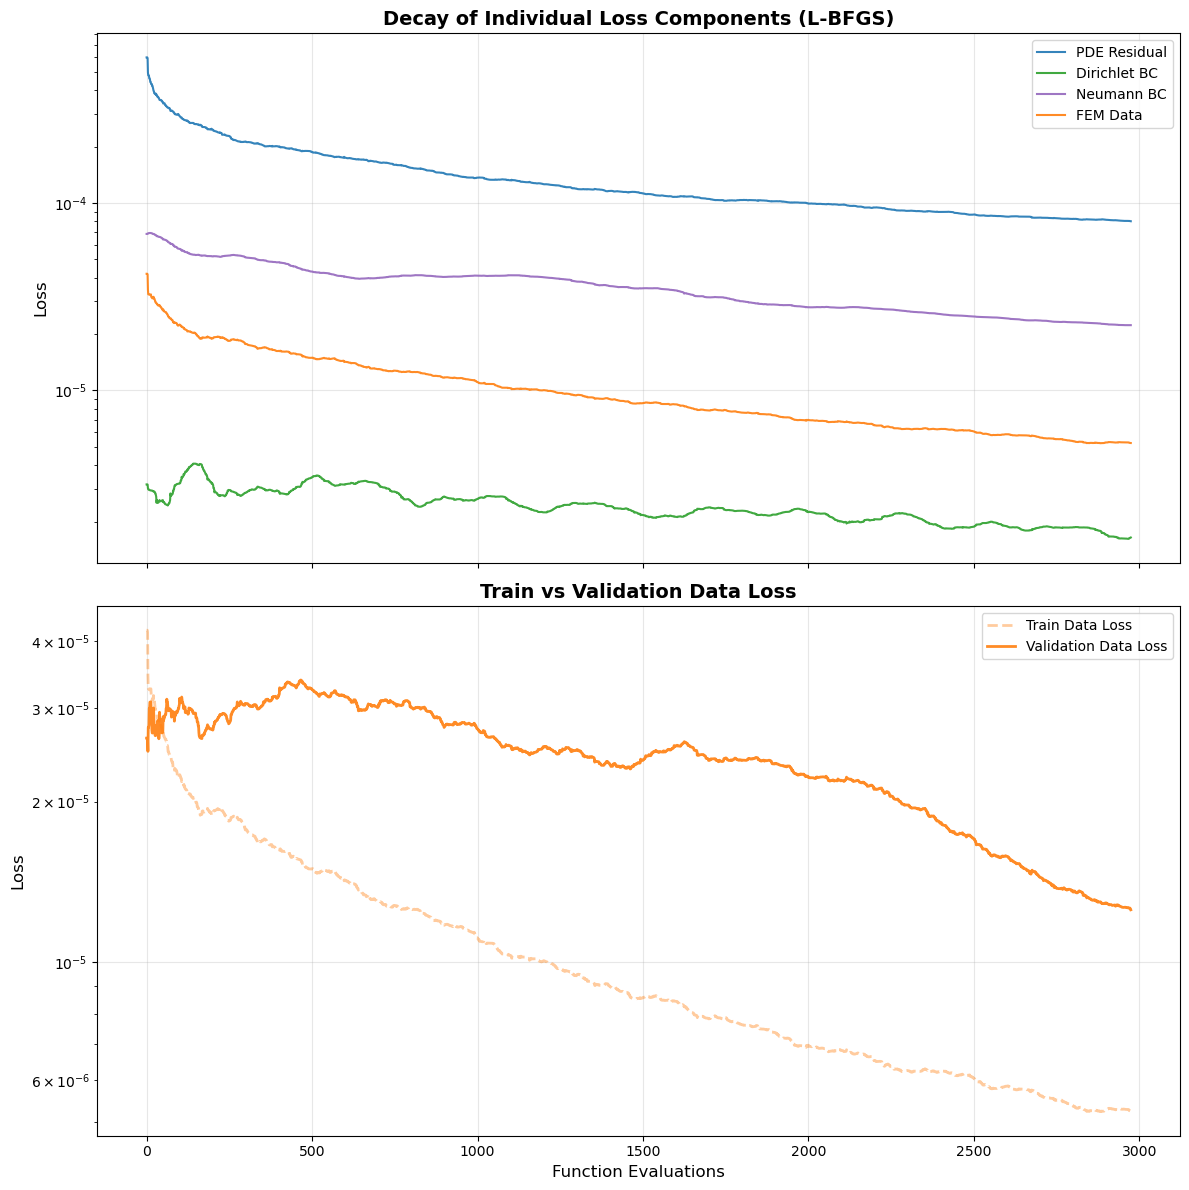

In [6]:
history_lbfgs_path = os.path.join(output_dir, 'decoder_lbfgs.loss.npz')
np.savez(history_lbfgs_path, **trainer.history_lbfgs)
plot_lbfgs_history(trainer.history_lbfgs)

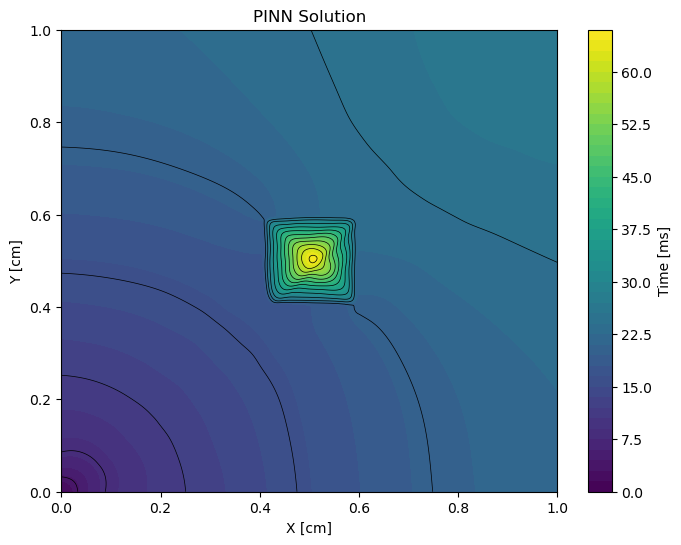

In [7]:
# PLOT
N_plot = 400
plot_pinn_solution(N_plot,model=model, U_SCALE=U_SCALE)

In [8]:
# TEST
u_pred = model(x_test_pinn)
test_mse = tf.reduce_mean(tf.square(u_pred - u_test_pinn)).numpy()
test_mae = tf.reduce_mean(tf.abs(u_pred - u_test_pinn)).numpy() * U_SCALE * 1000.0

print(f"Test MSE (Adimensionale): {test_mse:.6e}")
print(f"Test MAE (Fisico): {test_mae:.4f} ms")

Test MSE (Adimensionale): 2.760792e-05
Test MAE (Fisico): 0.0775 ms
